# Benchmark OLS vs SURE — prévision horaire de consommation de gaz

Deux modèles, tous deux structurés en **24 équations horaires** (une par heure locale Europe/Paris) avec les mêmes prédicteurs (Tableau 1) :
- **OLS horaire** : 24 régressions indépendantes (`models.ols.HourlyOLSModel`).
- **SURE** : même système estimé conjointement par FGLS, en exploitant la corrélation contemporaine des résidus entre heures d'un même jour (`models.sure.HourlySUREModel`).

**Split train/test** : train = 2018 → 2024, test = année civile **2025** (dernière année complète du dataset ; le reliquat partiel 2026 est exclu des deux, voir `models/dataset.py::split_train_test`).

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models.dataset import load_dataset, build_hourly_equations, split_train_test, target_series
from models.ols import HourlyOLSModel
from models.sure import HourlySUREModel
from models import metrics

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

df = load_dataset()
per_hour = build_hourly_equations(df)
train, test = split_train_test(per_hour, test_start="2025-01-01", test_end="2026-01-01")
print(f"train : {len(train[0])} jours | test : {len(test[0])} jours")

build_hourly_equations: panel équilibré sur 3055 jours (jours exclus par heure pour déséquilibre : {0: 10, 1: 14, 2: 5, 3: 13, 4: 14, 5: 14, 6: 14, 7: 14, 8: 14, 9: 14, 10: 14, 11: 14, 12: 14, 13: 14, 14: 14, 15: 14, 16: 14, 17: 14, 18: 14, 19: 14, 20: 14, 21: 13, 22: 13, 23: 13})
train : 2541 jours | test : 364 jours


In [2]:
ols = HourlyOLSModel().fit(train)
sure = HourlySUREModel().fit(train)

y_train, y_test = target_series(train), target_series(test)
preds = {
    ("OLS", "train"): ols.predict(train), ("OLS", "test"): ols.predict(test),
    ("SURE", "train"): sure.predict(train), ("SURE", "test"): sure.predict(test),
}

## 1. Métriques globales (train / test)

In [3]:
rows = []
for model_name in ("OLS", "SURE"):
    for split_name, y_true in (("train", y_train), ("test", y_test)):
        m = metrics.evaluate_overall(y_true, preds[(model_name, split_name)])
        rows.append({"modele": model_name, "split": split_name, **m})

summary = pd.DataFrame(rows).set_index(["modele", "split"])[["rmse", "mape", "mae", "n"]].round(2)
summary

rmse   mape       mae      n
modele split                                  
OLS    train   6163.34  11.66   4850.68  60984
       test   11335.72  30.21  10080.64   8736
SURE   train   6446.91  11.84   4991.03  60984
       test   11484.49  30.35  10074.01   8736

In [4]:
test_rmse_ols = summary.loc[("OLS", "test"), "rmse"]
test_rmse_sure = summary.loc[("SURE", "test"), "rmse"]
winner = "SURE" if test_rmse_sure < test_rmse_ols else "OLS"
gap_pct = abs(test_rmse_sure - test_rmse_ols) / test_rmse_ols * 100
print(f"Sur le test 2025, {winner} a le RMSE le plus bas "
      f"(OLS={test_rmse_ols:.0f} MW, SURE={test_rmse_sure:.0f} MW, écart={gap_pct:.1f}%).")

Sur le test 2025, OLS a le RMSE le plus bas (OLS=11336 MW, SURE=11484 MW, écart=1.3%).


## 2. RMSE par heure locale (test 2025)
Où chaque modèle se trompe le plus dans la journée (ex. heures de pointe matinale vs. creux nocturne).

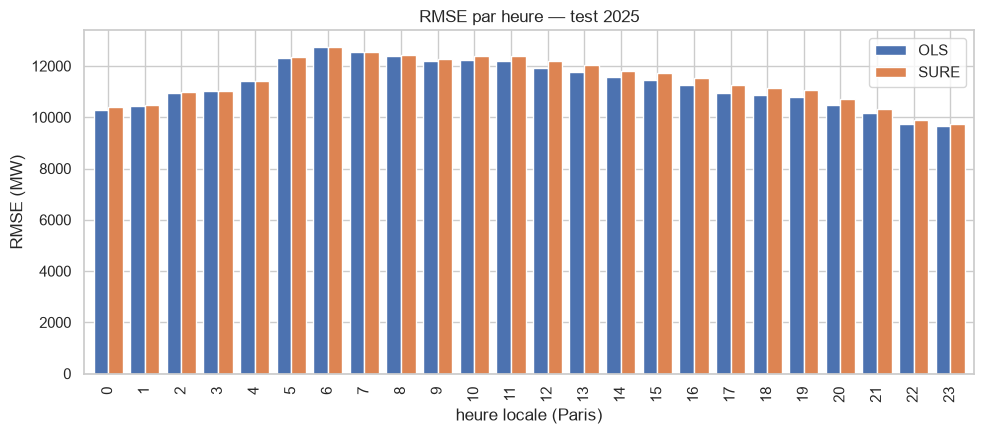

In [5]:
hourly_rmse = pd.DataFrame({
    "OLS": metrics.evaluate_hourly(y_test, preds[("OLS", "test")])["rmse"],
    "SURE": metrics.evaluate_hourly(y_test, preds[("SURE", "test")])["rmse"],
})

fig, ax = plt.subplots(figsize=(10, 4.5))
hourly_rmse.plot(kind="bar", ax=ax, width=0.8)
ax.set_xlabel("heure locale (Paris)")
ax.set_ylabel("RMSE (MW)")
ax.set_title("RMSE par heure — test 2025")
plt.tight_layout()
plt.show()

## 3. Prédictions vs réel — fenêtre hiver (2 semaines, test 2025)
Période de forte demande de chauffe : c'est là que le bloc thermique (X1/X2) est le plus sollicité.

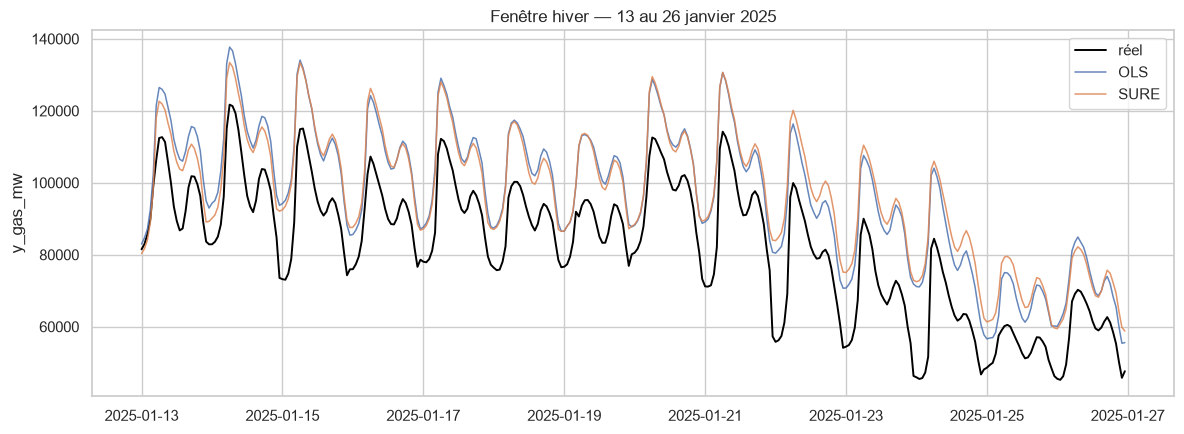

In [6]:
def plot_window(start, end, title):
    actual = metrics.combine_hourly(y_test).loc[start:end]
    ols_line = metrics.combine_hourly(preds[("OLS", "test")]).loc[start:end]
    sure_line = metrics.combine_hourly(preds[("SURE", "test")]).loc[start:end]

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(actual.index, actual.values, label="réel", color="black", linewidth=1.4)
    ax.plot(ols_line.index, ols_line.values, label="OLS", linewidth=1.1, alpha=0.85)
    ax.plot(sure_line.index, sure_line.values, label="SURE", linewidth=1.1, alpha=0.85)
    ax.set_ylabel("y_gas_mw")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_window("2025-01-13", "2025-01-26", "Fenêtre hiver — 13 au 26 janvier 2025")

## 4. Prédictions vs réel — fenêtre été (2 semaines, test 2025)
Période hors-chauffe : la consommation devrait être basse et plate, portée surtout par le fond de roulement (`beta_0`) et les effets calendaires.

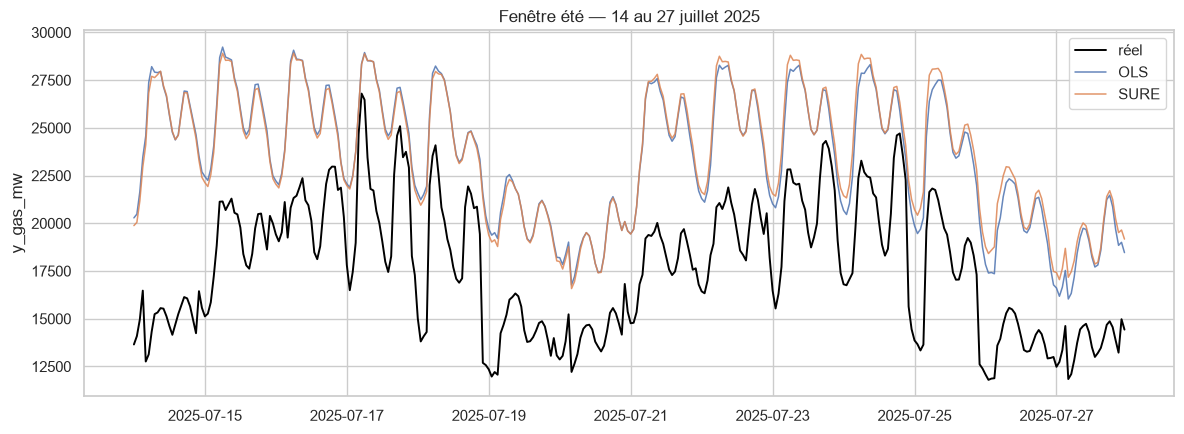

In [7]:
plot_window("2025-07-14", "2025-07-27", "Fenêtre été — 14 au 27 juillet 2025")